<a href="https://colab.research.google.com/github/Imran1hp/Machine-Learning/blob/main/Gradient_boosting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [120]:
!pip install numpy pandas matplotlib seaborn --quiet

In [121]:
!pip install opendatasets xgboost graphviz lightgbm scikit-learn xgboost lightgbm --upgrade --quiet

In [122]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import opendatasets as od


In [123]:
od.download("https://www.kaggle.com/c/rossmann-store-sales")

Skipping, found downloaded files in "./rossmann-store-sales" (use force=True to force download)


In [124]:
os.listdir('rossmann-store-sales')

['train.csv', 'store.csv', 'sample_submission.csv', 'test.csv']

In [125]:
ross_df = pd.read_csv('./rossmann-store-sales/train.csv',low_memory=False)
store_df = pd.read_csv('./rossmann-store-sales/store.csv')
test_df = pd.read_csv('./rossmann-store-sales/test.csv')
submission_df = pd.read_csv('./rossmann-store-sales/sample_submission.csv')

In [126]:
ross_df.head(20)

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1
5,6,5,2015-07-31,5651,589,1,1,0,1
6,7,5,2015-07-31,15344,1414,1,1,0,1
7,8,5,2015-07-31,8492,833,1,1,0,1
8,9,5,2015-07-31,8565,687,1,1,0,1
9,10,5,2015-07-31,7185,681,1,1,0,1


In [127]:
test_df

,Id,Store,DayOfWeek,Date,Open,Promo,StateHoliday,SchoolHoliday
0,1,1,4,2015-09-17,1.0,1,0,0
1,2,3,4,2015-09-17,1.0,1,0,0
2,3,7,4,2015-09-17,1.0,1,0,0
3,4,8,4,2015-09-17,1.0,1,0,0
4,5,9,4,2015-09-17,1.0,1,0,0
...,...,...,...,...,...,...,...,...
41083,41084,1111,6,2015-08-01,1.0,0,0,0
41084,41085,1112,6,2015-08-01,1.0,0,0,0
41085,41086,1113,6,2015-08-01,1.0,0,0,0
41086,41087,1114,6,2015-08-01,1.0,0,0,0


In [128]:
submission_df

,Id,Sales
0,1,0
1,2,0
2,3,0
3,4,0
4,5,0
...,...,...
41083,41084,0
41084,41085,0
41085,41086,0
41086,41087,0


In [129]:
store_df.head(20)

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN
5,6,a,a,310.0,12.0,2013.0,0,NaN,NaN,NaN
6,7,a,c,24000.0,4.0,2013.0,0,NaN,NaN,NaN
7,8,a,a,7520.0,10.0,2014.0,0,NaN,NaN,NaN
8,9,a,c,2030.0,8.0,2000.0,0,NaN,NaN,NaN
9,10,a,a,3160.0,9.0,2009.0,0,NaN,NaN,NaN


In [130]:
merge_df = ross_df.merge(store_df,how='left',on='Store')
merged_test_df =test_df.merge(store_df,how='left',on='Store')

In [131]:
merge_df

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1017204,1111,2,2013-01-01,0,0,0,0,a,1,a,a,1900.0,6.0,2014.0,1,31.0,2013.0,"Jan,Apr,Jul,Oct"
1017205,1112,2,2013-01-01,0,0,0,0,a,1,c,c,1880.0,4.0,2006.0,0,NaN,NaN,NaN
1017206,1113,2,2013-01-01,0,0,0,0,a,1,a,c,9260.0,NaN,NaN,0,NaN,NaN,NaN
1017207,1114,2,2013-01-01,0,0,0,0,a,1,a,c,870.0,NaN,NaN,0,NaN,NaN,NaN


In [132]:
merge_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 18 columns):
 #   Column                     Non-Null Count    Dtype  
---  ------                     --------------    -----  
 0   Store                      1017209 non-null  int64  
 1   DayOfWeek                  1017209 non-null  int64  
 2   Date                       1017209 non-null  object 
 3   Sales                      1017209 non-null  int64  
 4   Customers                  1017209 non-null  int64  
 5   Open                       1017209 non-null  int64  
 6   Promo                      1017209 non-null  int64  
 7   StateHoliday               1017209 non-null  object 
 8   SchoolHoliday              1017209 non-null  int64  
 9   StoreType                  1017209 non-null  object 
 10  Assortment                 1017209 non-null  object 
 11  CompetitionDistance        1014567 non-null  float64
 12  CompetitionOpenSinceMonth  693861 non-null   float64
 13  CompetitionO

In [133]:
def split_date(df):
  df["Date"] = pd.to_datetime(df['Date'])
  df['Year'] = df.Date.dt.year
  df['Month'] = df.Date.dt.month
  df['Day'] = df.Date.dt.day
  df['WeekOfYear'] = df.Date.dt.isocalendar().week.astype(int)

In [134]:
split_date(merge_df)
split_date(merged_test_df)

In [135]:
merge_df

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,...,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,Year,Month,Day,WeekOfYear
0,1,5,2015-07-31,5263,555,1,1,0,1,c,...,9.0,2008.0,0,NaN,NaN,NaN,2015,7,31,31
1,2,5,2015-07-31,6064,625,1,1,0,1,a,...,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct",2015,7,31,31
2,3,5,2015-07-31,8314,821,1,1,0,1,a,...,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct",2015,7,31,31
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,...,9.0,2009.0,0,NaN,NaN,NaN,2015,7,31,31
4,5,5,2015-07-31,4822,559,1,1,0,1,a,...,4.0,2015.0,0,NaN,NaN,NaN,2015,7,31,31
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1017204,1111,2,2013-01-01,0,0,0,0,a,1,a,...,6.0,2014.0,1,31.0,2013.0,"Jan,Apr,Jul,Oct",2013,1,1,1
1017205,1112,2,2013-01-01,0,0,0,0,a,1,c,...,4.0,2006.0,0,NaN,NaN,NaN,2013,1,1,1
1017206,1113,2,2013-01-01,0,0,0,0,a,1,a,...,NaN,NaN,0,NaN,NaN,NaN,2013,1,1,1
1017207,1114,2,2013-01-01,0,0,0,0,a,1,a,...,NaN,NaN,0,NaN,NaN,NaN,2013,1,1,1


In [136]:
merge_df[merge_df.Open == 0].Sales.value_counts()

,count
Sales,
0,172817


In [137]:
merged_df = merge_df[merge_df.Open==1].copy()

In [138]:
merged_df[merged_df.Open ==0].Sales.value_counts()

,count
Sales,


In [139]:
def comp_months(df):
  df['CompetitionOpen']= 12*(df.Year-df.CompetitionOpenSinceYear)+(df.Month-df.CompetitionOpenSinceMonth)
  df['CompetitionOpen'] =df['CompetitionOpen'].map(lambda x: 0 if x<0 else x).fillna(0)

In [140]:
comp_months(merged_df)
comp_months(merged_test_df)

In [141]:
merged_df

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,...,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,Year,Month,Day,WeekOfYear,CompetitionOpen
0,1,5,2015-07-31,5263,555,1,1,0,1,c,...,2008.0,0,NaN,NaN,NaN,2015,7,31,31,82.0
1,2,5,2015-07-31,6064,625,1,1,0,1,a,...,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct",2015,7,31,31,92.0
2,3,5,2015-07-31,8314,821,1,1,0,1,a,...,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct",2015,7,31,31,103.0
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,...,2009.0,0,NaN,NaN,NaN,2015,7,31,31,70.0
4,5,5,2015-07-31,4822,559,1,1,0,1,a,...,2015.0,0,NaN,NaN,NaN,2015,7,31,31,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1016776,682,2,2013-01-01,3375,566,1,0,a,1,b,...,2006.0,0,NaN,NaN,NaN,2013,1,1,1,76.0
1016827,733,2,2013-01-01,10765,2377,1,0,a,1,b,...,1999.0,0,NaN,NaN,NaN,2013,1,1,1,159.0
1016863,769,2,2013-01-01,5035,1248,1,0,a,1,b,...,NaN,1,48.0,2012.0,"Jan,Apr,Jul,Oct",2013,1,1,1,0.0
1017042,948,2,2013-01-01,4491,1039,1,0,a,1,b,...,NaN,0,NaN,NaN,NaN,2013,1,1,1,0.0


In [142]:
merged_df[['Date','CompetitionOpenSinceYear','CompetitionOpenSinceMonth','CompetitionOpen']].sample(20)

,Date,CompetitionOpenSinceYear,CompetitionOpenSinceMonth,CompetitionOpen
778107,2013-08-03,2011.0,3.0,29.0
595715,2014-01-14,NaN,NaN,0.0
407187,2014-07-02,NaN,NaN,0.0
921975,2013-03-27,2009.0,4.0,47.0
273240,2014-11-22,2005.0,9.0,110.0
122246,2015-04-13,2007.0,9.0,91.0
32603,2015-07-02,2015.0,6.0,1.0
180512,2015-02-20,2005.0,9.0,113.0
506357,2014-04-04,2005.0,2.0,110.0
429428,2014-06-12,NaN,NaN,0.0


In [143]:
def check_promo_month(row):
  month2str ={
      1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',7:'Jul',8:'Aug',9:'Sept',
      10:'Oct',11:'Nov',12:'Dec'}
  try:
    months=(row['PromoInterval'] or '').split(',')
    if row['Promo2Open'] and month2str[row['Month']] in months:
      return 1
    else:
      return 0
  except Exception:
    return 0
def promo_cols(df):
  df['Promo2Open'] = 12*(df.Year - df.Promo2SinceYear) + (df.WeekOfYear -df.Promo2SinceWeek)*7/30.5
  df['Promo2Open'] =df['Promo2Open'].map(lambda x: 0 if x<0 else x).fillna(0)
  df['IsPromo2Month'] = df.apply(check_promo_month,axis=1)*df['Promo2']




In [144]:
promo_cols(merged_df)

In [145]:
promo_cols(merged_test_df)

In [146]:
merged_df[['Date','Promo2','Promo2SinceYear','Promo2SinceWeek','PromoInterval','Promo2Open','IsPromo2Month']].sample(20)

,Date,Promo2,Promo2SinceYear,Promo2SinceWeek,PromoInterval,Promo2Open,IsPromo2Month
256180,2014-12-10,0,NaN,NaN,NaN,0.000000,0
399469,2014-07-10,1,2011.0,14.0,"Mar,Jun,Sept,Dec",39.213115,0
691190,2013-10-20,0,NaN,NaN,NaN,0.000000,0
394964,2014-07-15,1,2009.0,37.0,"Jan,Apr,Jul,Oct",58.163934,1
419905,2014-06-20,0,NaN,NaN,NaN,0.000000,0
49462,2015-06-17,0,NaN,NaN,NaN,0.000000,0
885084,2013-04-29,0,NaN,NaN,NaN,0.000000,0
301537,2014-10-23,0,NaN,NaN,NaN,0.000000,0
914251,2013-04-03,1,2013.0,31.0,"Jan,Apr,Jul,Oct",0.000000,0
140272,2015-03-28,0,NaN,NaN,NaN,0.000000,0


In [147]:
merged_df.columns

Index(['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo',
       'StateHoliday', 'SchoolHoliday', 'StoreType', 'Assortment',
       'CompetitionDistance', 'CompetitionOpenSinceMonth',
       'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek',
       'Promo2SinceYear', 'PromoInterval', 'Year', 'Month', 'Day',
       'WeekOfYear', 'CompetitionOpen', 'Promo2Open', 'IsPromo2Month'],
      dtype='object')

In [148]:
input_cols=['Store','DayOfWeek','Promo','StateHoliday','SchoolHoliday','StoreType','Assortment','CompetitionDistance','CompetitionOpen','Day','Month','Year','Promo2','Promo2Open','IsPromo2Month']
target_cols='Sales'

In [149]:
inputs=merged_df[input_cols].copy()
targets=merged_df[target_cols].copy()

In [150]:
test_inputs=merged_test_df[input_cols].copy()

In [151]:
inputs

,Store,DayOfWeek,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpen,Day,Month,Year,Promo2,Promo2Open,IsPromo2Month
0,1,5,1,0,1,c,a,1270.0,82.0,31,7,2015,0,0.000000,0
1,2,5,1,0,1,a,a,570.0,92.0,31,7,2015,1,64.131148,1
2,3,5,1,0,1,a,a,14130.0,103.0,31,7,2015,1,51.901639,1
3,4,5,1,0,1,c,c,620.0,70.0,31,7,2015,0,0.000000,0
4,5,5,1,0,1,a,a,29910.0,3.0,31,7,2015,0,0.000000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1016776,682,2,0,a,1,b,a,150.0,76.0,1,1,2013,0,0.000000,0
1016827,733,2,0,a,1,b,b,860.0,159.0,1,1,2013,0,0.000000,0
1016863,769,2,0,a,1,b,b,840.0,0.0,1,1,2013,1,1.213115,1
1017042,948,2,0,a,1,b,b,1430.0,0.0,1,1,2013,0,0.000000,0


In [152]:
numeric_cols=['Store','Promo','SchoolHoliday','CompetitionDistance','CompetitionOpen','Day','Month','Year','Promo2','Promo2Open','IsPromo2Month']
categorical_cols=['DayOfWeek','StateHoliday','SchoolHoliday','StoreType','Assortment']

In [153]:
inputs[numeric_cols].isna().sum()

,0
Store,0
Promo,0
SchoolHoliday,0
CompetitionDistance,2186
CompetitionOpen,0
Day,0
Month,0
Year,0
Promo2,0
Promo2Open,0


In [154]:
test_inputs[numeric_cols].isna().sum()

,0
Store,0
Promo,0
SchoolHoliday,0
CompetitionDistance,96
CompetitionOpen,0
Day,0
Month,0
Year,0
Promo2,0
Promo2Open,0


In [167]:
max_distance = inputs.CompetitionDistance.max()
inputs.CompetitionDistance.fillna(max_distance*2,inplace=True)
test_inputs.CompetitionDistance.fillna(max_distance*2,inplace =True)

/tmp/ipython-input-4047775763.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  inputs.CompetitionDistance.fillna(max_distance*2,inplace=True)
/tmp/ipython-input-4047775763.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=

In [168]:
inputs[numeric_cols].isna().sum()

,0
Store,0
Promo,0
SchoolHoliday,0
CompetitionDistance,0
CompetitionOpen,0
Day,0
Month,0
Year,0
Promo2,0
Promo2Open,0


In [169]:
from sklearn.preprocessing import MinMaxScaler

In [170]:
scaler = MinMaxScaler().fit(inputs[numeric_cols])

In [171]:
inputs[numeric_cols]=scaler.transform(inputs[numeric_cols])
test_inputs[numeric_cols]=scaler.transform(test_inputs[numeric_cols])

In [172]:
from sklearn.preprocessing import OneHotEncoder

In [173]:
encoder =OneHotEncoder(sparse_output=False ,handle_unknown='ignore').fit(inputs[categorical_cols])
encoded_cols = list(encoder.get_feature_names_out(categorical_cols))


In [174]:
inputs[encoded_cols]= encoder.transform(inputs[categorical_cols])
test_inputs[encoded_cols] =encoder.transform(test_inputs[categorical_cols])

In [175]:
X = inputs[numeric_cols + encoded_cols]
X_test = test_inputs[numeric_cols + encoded_cols]

In [176]:
X

,Store,Promo,SchoolHoliday,CompetitionDistance,CompetitionOpen,Day,Month,Year,Promo2,Promo2Open,...,StateHoliday_c,SchoolHoliday_0.0,SchoolHoliday_1.0,StoreType_a,StoreType_b,StoreType_c,StoreType_d,Assortment_a,Assortment_b,Assortment_c
0,0.000000,1.0,1.0,0.016482,0.059163,1.0,0.545455,1.0,0.0,0.000000,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
1,0.000898,1.0,1.0,0.007252,0.066378,1.0,0.545455,1.0,1.0,0.890710,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
2,0.001795,1.0,1.0,0.186050,0.074315,1.0,0.545455,1.0,1.0,0.720856,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
3,0.002693,1.0,1.0,0.007911,0.050505,1.0,0.545455,1.0,0.0,0.000000,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
4,0.003591,1.0,1.0,0.394119,0.002165,1.0,0.545455,1.0,0.0,0.000000,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1016776,0.611311,0.0,1.0,0.001714,0.054834,0.0,0.000000,0.0,0.0,0.000000,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
1016827,0.657092,0.0,1.0,0.011076,0.114719,0.0,0.000000,0.0,0.0,0.000000,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1016863,0.689408,0.0,1.0,0.010812,0.000000,0.0,0.000000,0.0,1.0,0.016849,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1017042,0.850090,0.0,1.0,0.018592,0.000000,0.0,0.000000,0.0,0.0,0.000000,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


In [177]:
X_test

,Store,Promo,SchoolHoliday,CompetitionDistance,CompetitionOpen,Day,Month,Year,Promo2,Promo2Open,...,StateHoliday_c,SchoolHoliday_0.0,SchoolHoliday_1.0,StoreType_a,StoreType_b,StoreType_c,StoreType_d,Assortment_a,Assortment_b,Assortment_c
0,0.000000,1.0,0.0,0.016482,0.060606,0.533333,0.727273,1.0,0.0,0.000000,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
1,0.001795,1.0,0.0,0.186050,0.075758,0.533333,0.727273,1.0,1.0,0.743169,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
2,0.005386,1.0,0.0,0.316192,0.020924,0.533333,0.727273,1.0,0.0,0.000000,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0.006284,1.0,0.0,0.098892,0.007937,0.533333,0.727273,1.0,0.0,0.000000,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
4,0.007181,1.0,0.0,0.026503,0.130592,0.533333,0.727273,1.0,0.0,0.000000,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41083,0.996409,0.0,0.0,0.024789,0.010101,0.000000,0.636364,1.0,1.0,0.333333,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
41084,0.997307,0.0,0.0,0.024525,0.080808,0.000000,0.636364,1.0,0.0,0.000000,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
41085,0.998205,0.0,0.0,0.121835,0.000000,0.000000,0.636364,1.0,0.0,0.000000,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
41086,0.999102,0.0,0.0,0.011208,0.000000,0.000000,0.636364,1.0,0.0,0.000000,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0


In [178]:
X_test.describe()

,Store,Promo,SchoolHoliday,CompetitionDistance,CompetitionOpen,Day,Month,Year,Promo2,Promo2Open,...,StateHoliday_c,SchoolHoliday_0.0,SchoolHoliday_1.0,StoreType_a,StoreType_b,StoreType_c,StoreType_d,Assortment_a,Assortment_b,Assortment_c
count,41088.000000,41088.000000,41088.000000,41088.000000,41088.000000,41088.000000,41088.000000,41088.0,41088.000000,41088.000000,...,41088.0,41088.000000,41088.000000,41088.000000,41088.000000,41088.000000,41088.000000,41088.000000,41088.000000,41088.000000
mean,0.498114,0.395833,0.443487,0.069013,0.035262,0.417361,0.668561,1.0,0.580607,0.326546,...,0.0,0.556513,0.443487,0.538551,0.014019,0.103972,0.343458,0.494159,0.010514,0.495327
std,0.287500,0.489035,0.496802,0.105288,0.054313,0.281615,0.043479,0.0,0.493466,0.348285,...,0.0,0.496802,0.496802,0.498518,0.117569,0.305228,0.474868,0.499972,0.101999,0.499984
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.636364,1.0,0.000000,0.000000,...,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.250224,0.000000,0.000000,0.009230,0.000000,0.191667,0.636364,1.0,0.000000,0.000000,...,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.495961,0.000000,0.000000,0.032041,0.020202,0.383333,0.636364,1.0,1.000000,0.236794,...,0.0,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.746185,1.000000,1.000000,0.085970,0.059885,0.608333,0.727273,1.0,1.000000,0.641166,...,0.0,1.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.001443,1.000000,0.727273,1.0,1.000000,1.022313,...,0.0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [179]:
from xgboost import XGBRegressor

In [180]:
model = XGBRegressor(random_state=42,n_jobs=-1,n_estimators=20,max_depth=4)

In [181]:
model.fit(X,targets)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [182]:
preds= model.predict(X)

In [183]:
preds

array([8151.662, 7664.8  , 9152.549, ..., 7189.141, 8943.833, 9884.116],
      dtype=float32)

In [184]:
from sklearn.metrics import mean_squared_error

In [188]:
def rmse(a,b):
  return np.sqrt(mean_squared_error(a,b))

In [189]:
rmse(preds,targets)

np.float64(2385.463791383135)

In [193]:
from xgboost import plot_tree
from matplotlib.pylab import rcParams
rcParams['figure.figsize'] =30,30

/usr/local/lib/python3.12/dist-packages/xgboost/plotting.py:267: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(


<Axes: >

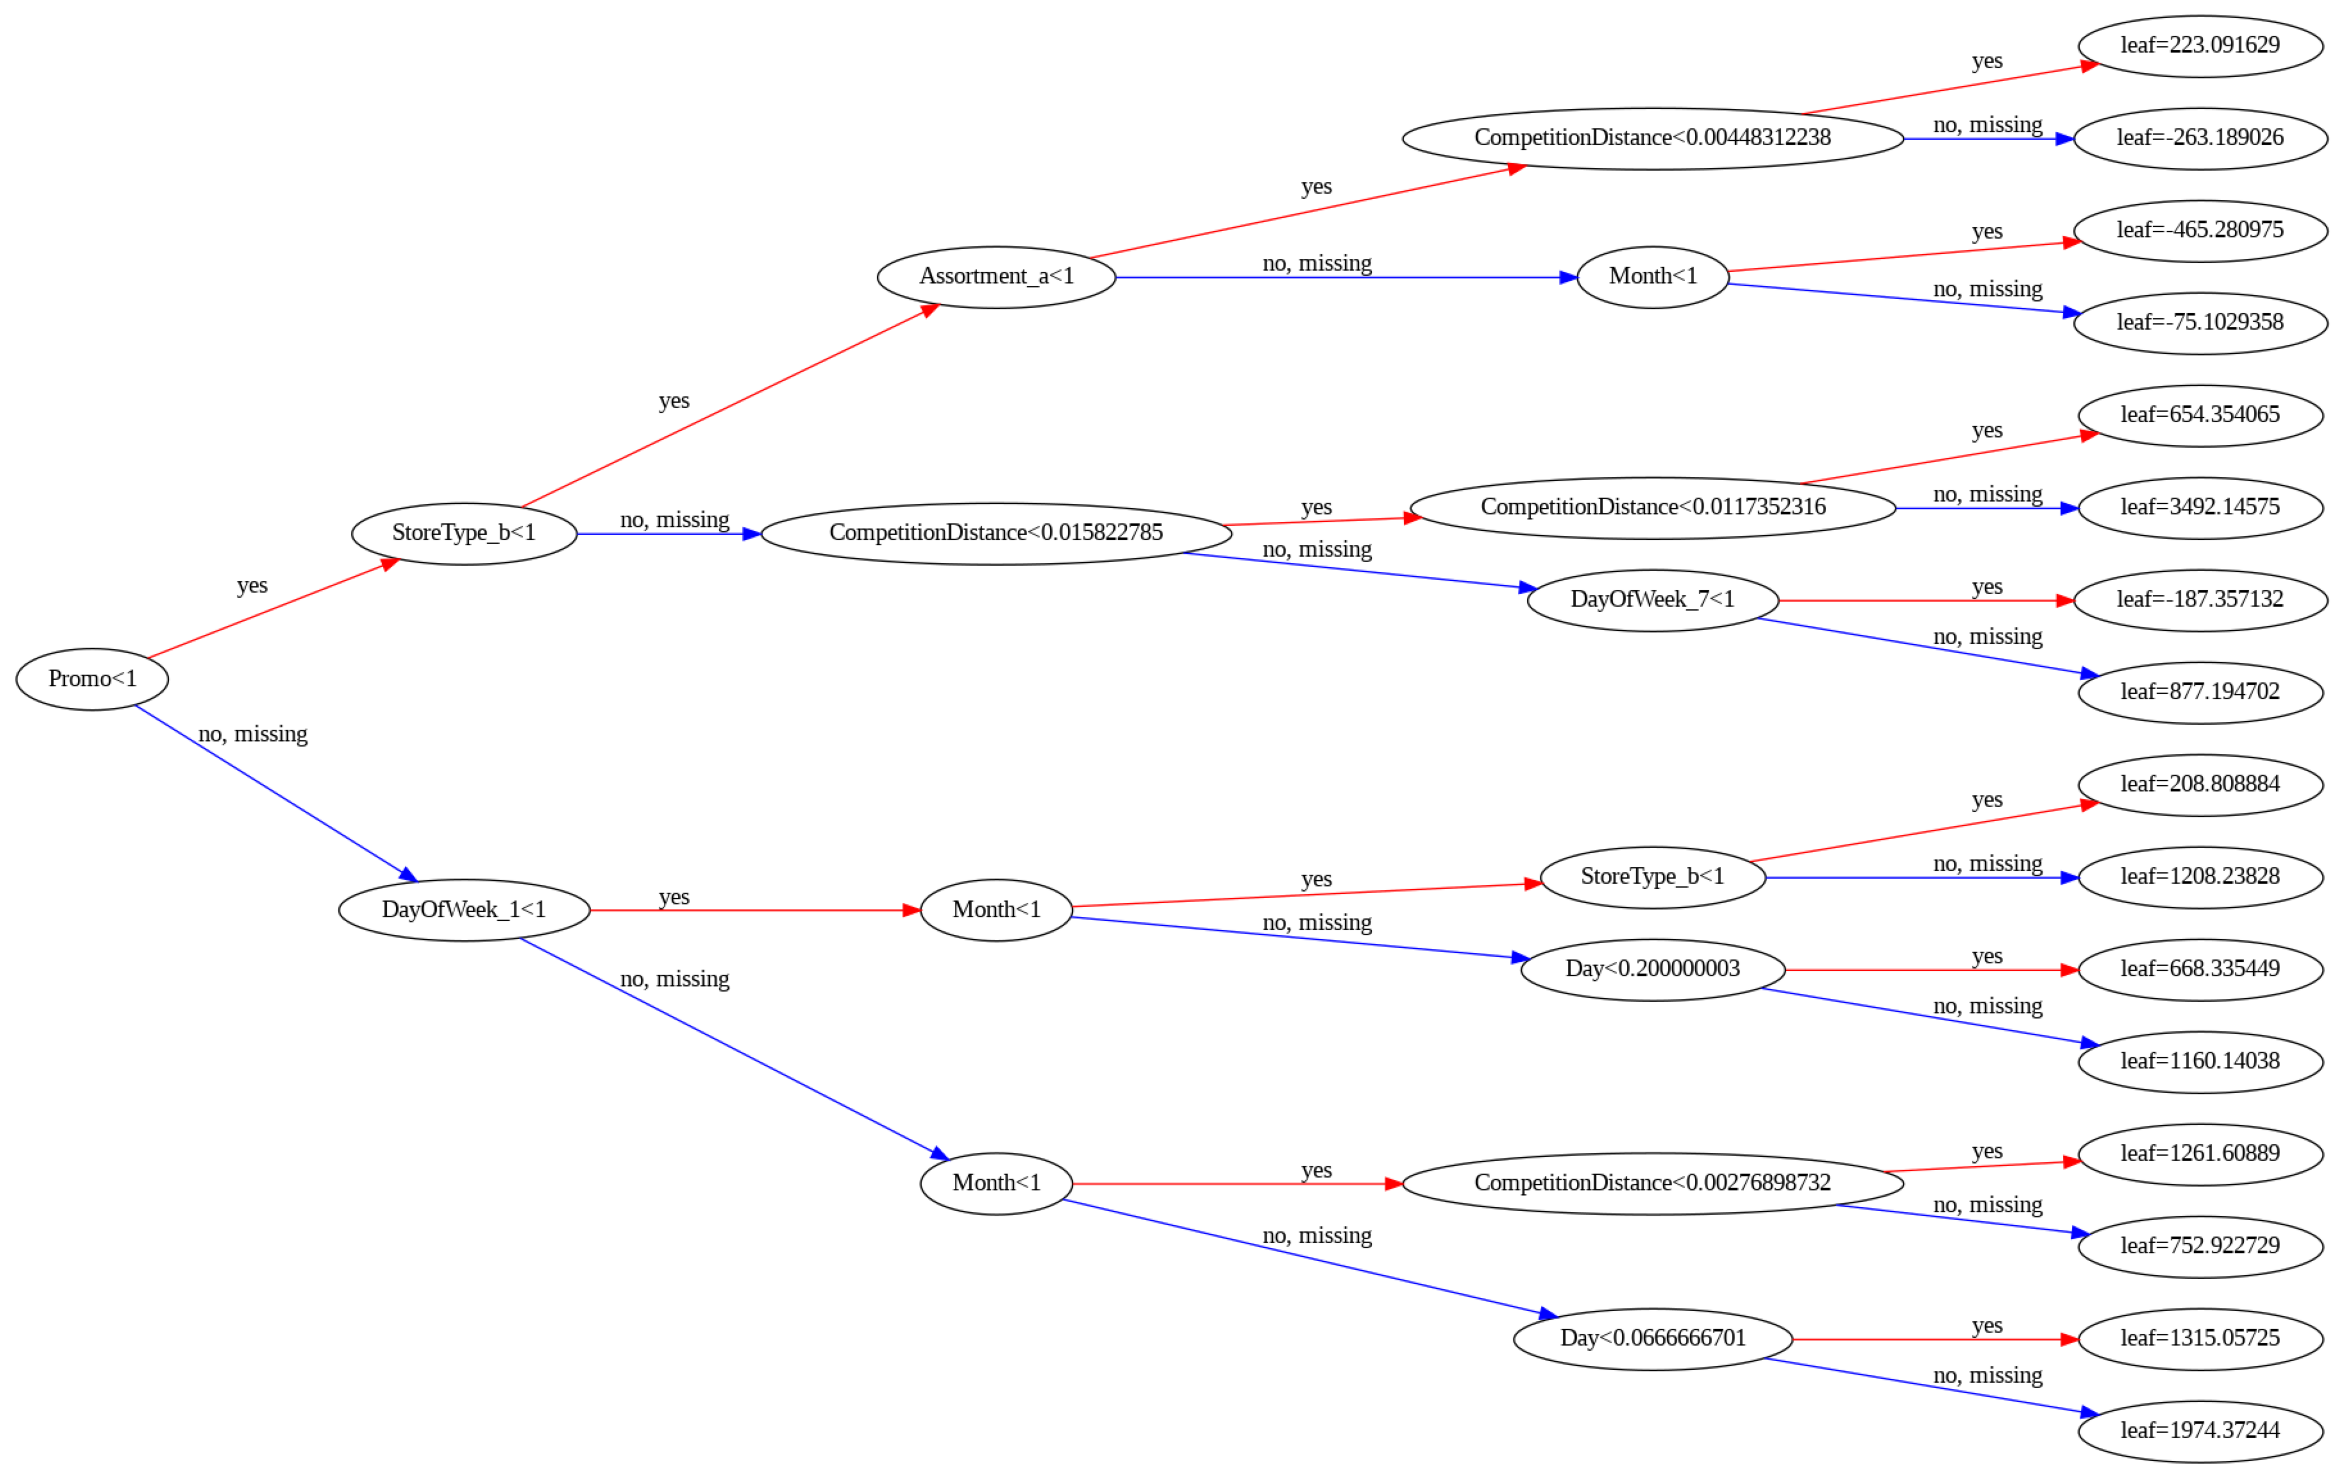

In [194]:
plot_tree(model,rankdir='LR',num_trees=0)

In [196]:
importance_df = pd.DataFrame({
    'feature':X.columns,
    'importance':model.feature_importances_
}).sort_values('importance',ascending=False)

In [198]:
importance_df.head(10)

,feature,importance
1,Promo,0.361458
11,DayOfWeek_1,0.099170
25,StoreType_b,0.064714
8,Promo2,0.053634
28,Assortment_a,0.046960
30,Assortment_c,0.041973
3,CompetitionDistance,0.039677
2,SchoolHoliday,0.035447
26,StoreType_c,0.034448
6,Month,0.027711


<Axes: xlabel='importance', ylabel='feature'>

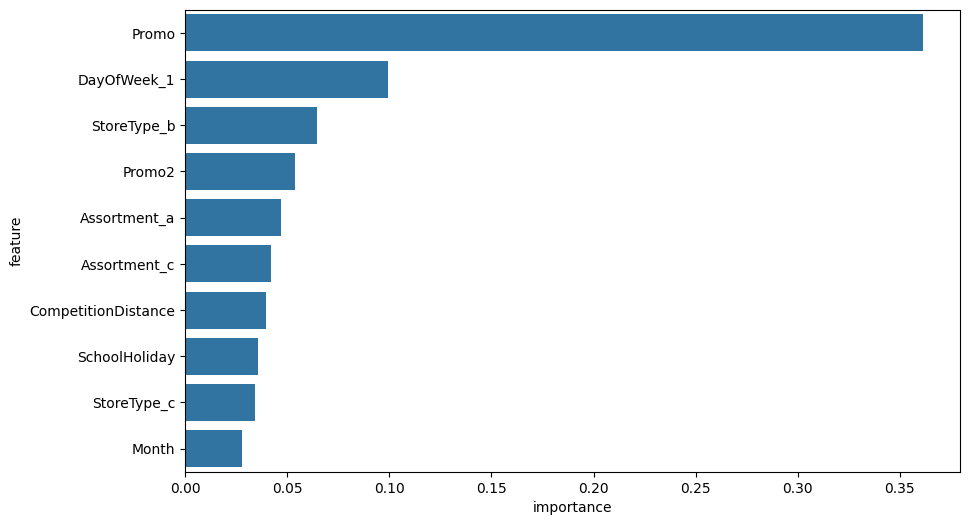

In [199]:
import seaborn as sns
plt.figure(figsize=(10,6))
sns.barplot(data=importance_df.head(10),x='importance',y='feature')